In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path(".../src").resolve()))

import json

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
from PIL import Image
import pandas as pd

from entrenament import dibuixa_comparacio_metodes

ARREL = Path("/home/jms/PhaseSpectrum/resultats")
RUTA_1VS1 = ARREL / "1VS1"
RUTA_MESCLA = ARREL / "MESCLA"

EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
METODES_FAKE = ["pggan_v1", "pggan_v2", "stargan", "stylegan_celeba", "stylegan_ffhq"]

In [5]:
def carrega_json(ruta_json):
    with open(ruta_json, "r", encoding="utf-8") as fitxer:
        return json.load(fitxer)


def mostra_grafics(ruta_grafics, titol=""):
    imatges = sorted([p for p in ruta_grafics.iterdir() if p.suffix.lower() in EXTENSIONS])

    fig = plt.figure(figsize=(28, 7))
    grid = ImageGrid(
        fig,
        111,
        nrows_ncols=(1, 4),
        axes_pad=0.25
    )

    for ax, ruta_img in zip(grid, imatges):
        img = Image.open(ruta_img)
        ax.imshow(img)
        ax.set_title(ruta_img.stem, fontsize=10)
        ax.axis("off")

    plt.suptitle(titol, fontsize=16)
    plt.subplots_adjust(top=0.82)
    plt.show()


def mostra_resum_metriques(contingut):
    metriques = contingut["Metriques"]

    print("Nom experiment:", contingut["Nom experiment"])
    print("Metode fake:", contingut["Metode fake"])
    print("Num epoques:", contingut["Num epoques"])
    print("Batch size:", contingut["Batch size"])
    print("Learning rate:", contingut["Learning rate"])
    print("Test loss:", contingut["Test loss"])
    print("Accuracy:", metriques["accuracy"])
    print("Precision:", metriques["precision"])
    print("Recall:", metriques["recall"])
    print("F1:", metriques["f1"])
    print("AUC:", metriques["auc"])

## EXPERIMENT 1VS1


Experiment 1VS1 - pggan_v1


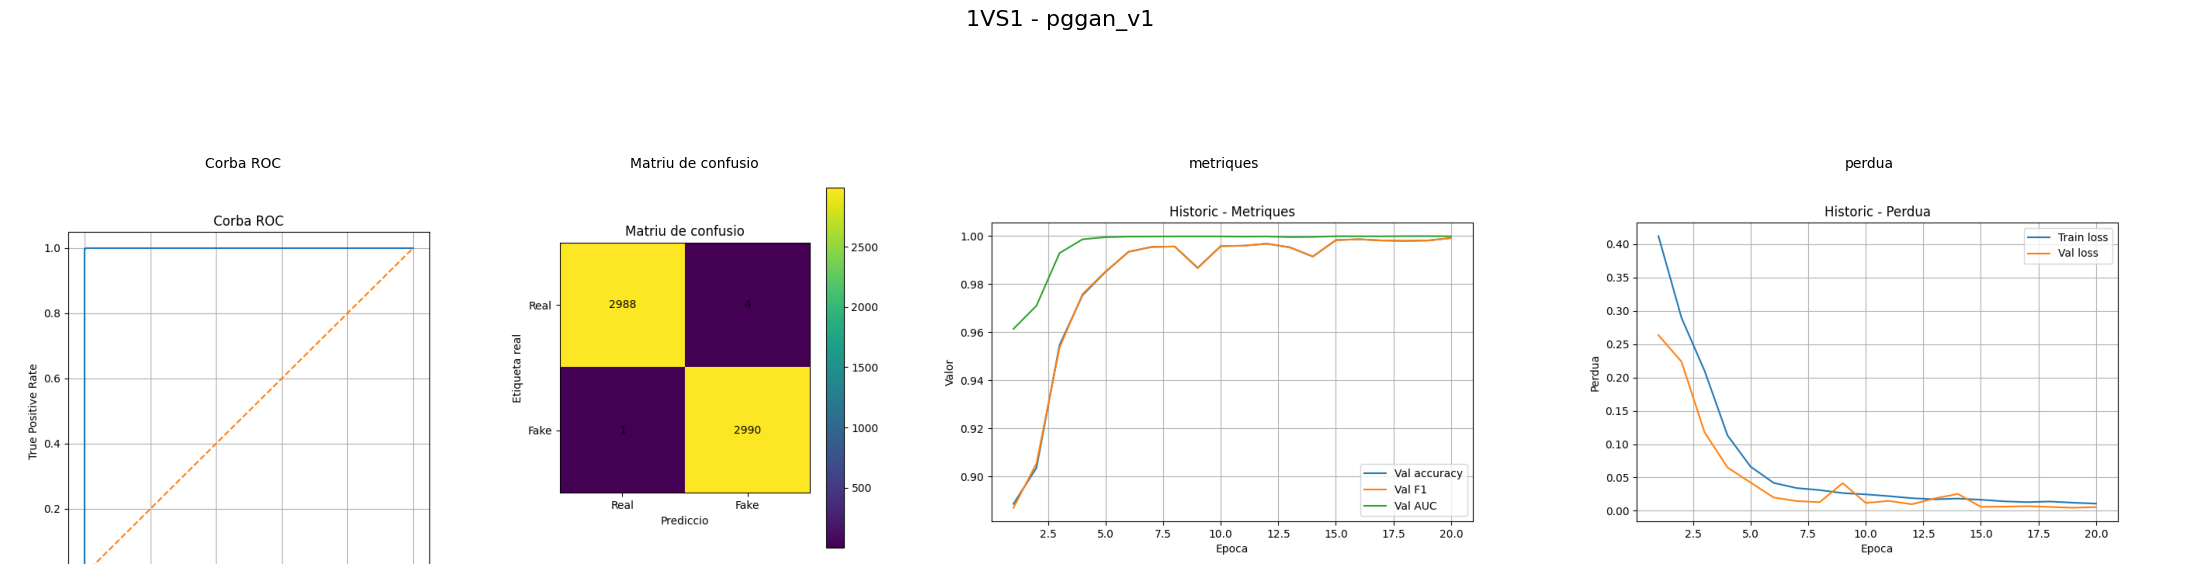

Nom experiment: 1VS1
Metode fake: pggan_v1
Num epoques: 20
Batch size: 16
Learning rate: 0.001
Test loss: 0.004496898363406654
Accuracy: 0.9991642988467324
Precision: 0.9986639946559787
Recall: 0.9996656636576395
F1: 0.9991645781119465
AUC: 0.9999477040747912

Experiment 1VS1 - pggan_v2


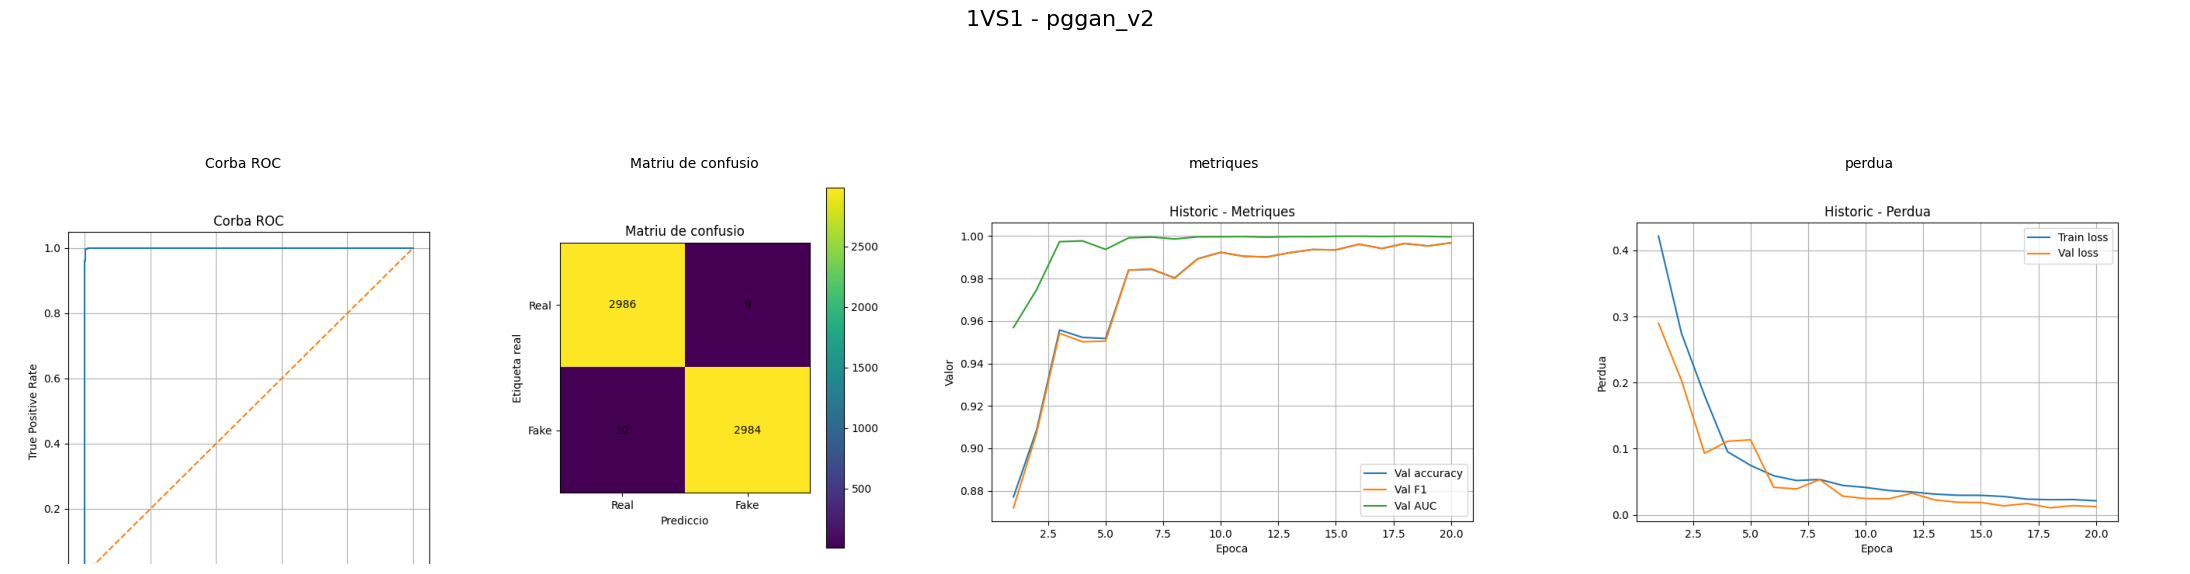

Nom experiment: 1VS1
Metode fake: pggan_v2
Num epoques: 20
Batch size: 16
Learning rate: 0.001
Test loss: 0.01220338645412994
Accuracy: 0.9968275171147103
Precision: 0.9969929836284664
Recall: 0.9966599866399466
F1: 0.9968264573242024
AUC: 0.9998747634389537

Experiment 1VS1 - stargan


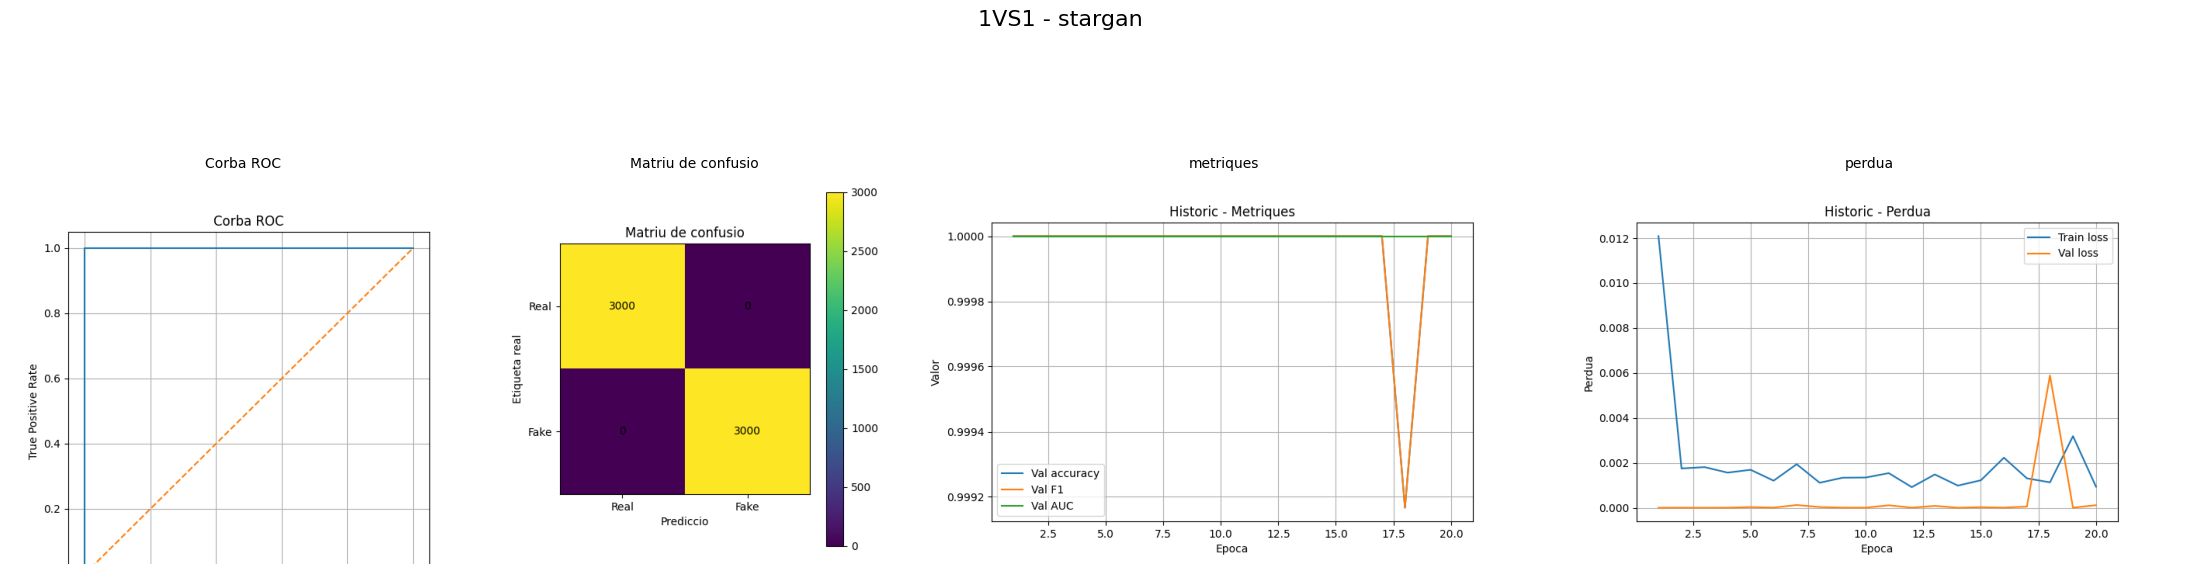

Nom experiment: 1VS1
Metode fake: stargan
Num epoques: 20
Batch size: 16
Learning rate: 0.001
Test loss: 0.00013149155778304097
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
AUC: 1.0

Experiment 1VS1 - stylegan_celeba


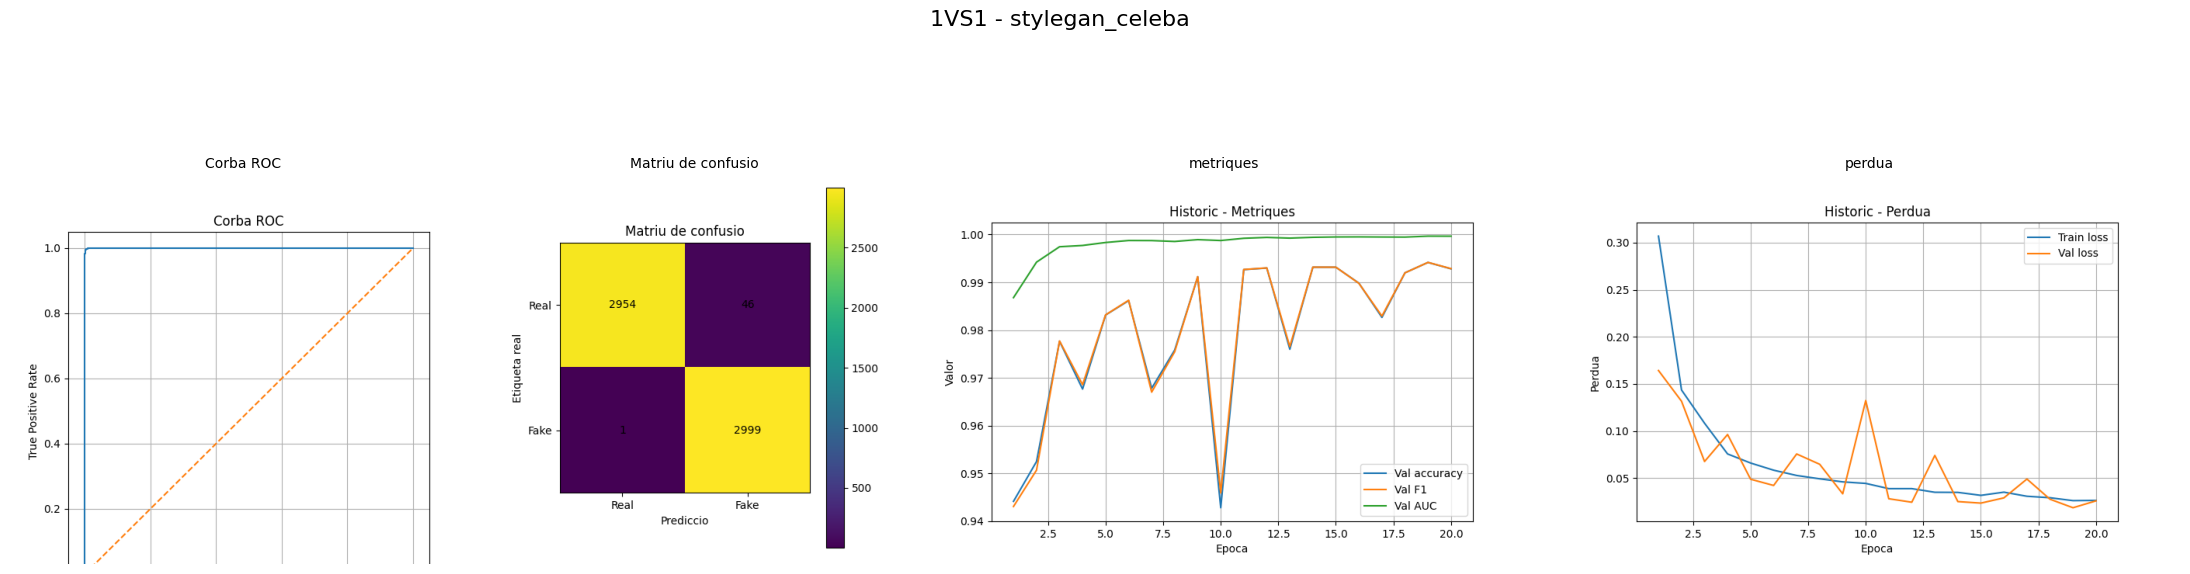

Nom experiment: 1VS1
Metode fake: stylegan_celeba
Num epoques: 20
Batch size: 16
Learning rate: 0.001
Test loss: 0.0205524844712063
Accuracy: 0.9921666666666666
Precision: 0.9848932676518883
Recall: 0.9996666666666667
F1: 0.9922249793217535
AUC: 0.9999244444444445

Experiment 1VS1 - stylegan_ffhq


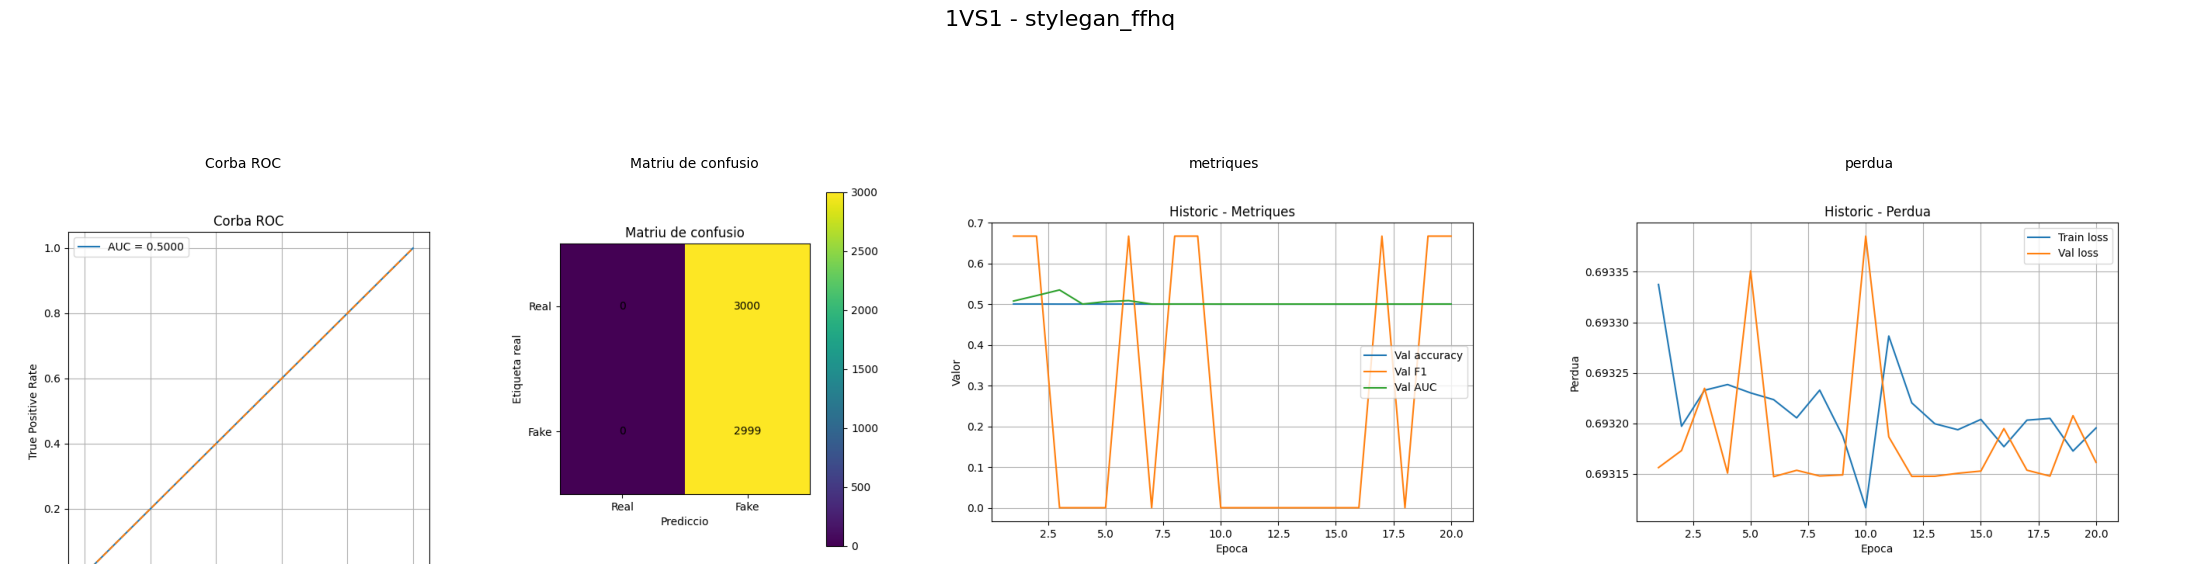

Nom experiment: 1VS1
Metode fake: stylegan_ffhq
Num epoques: 20
Batch size: 16
Learning rate: 0.001
Test loss: 0.693163669427236
Accuracy: 0.4999166527754626
Precision: 0.4999166527754626
Recall: 1.0
F1: 0.6665925761280285
AUC: 0.5


In [6]:
for metode in METODES_FAKE:
    ruta_metode = RUTA_1VS1 / metode
    contingut = carrega_json(ruta_metode / "metriques.json")

    print("\n" + "=" * 60)
    print(f"Experiment 1VS1 - {metode}")
    print("=" * 60)

    mostra_grafics(ruta_metode / "grafics", titol=f"1VS1 - {metode}")
    mostra_resum_metriques(contingut)

## EXPERIMENT MESCLA


Experiment MESCLA


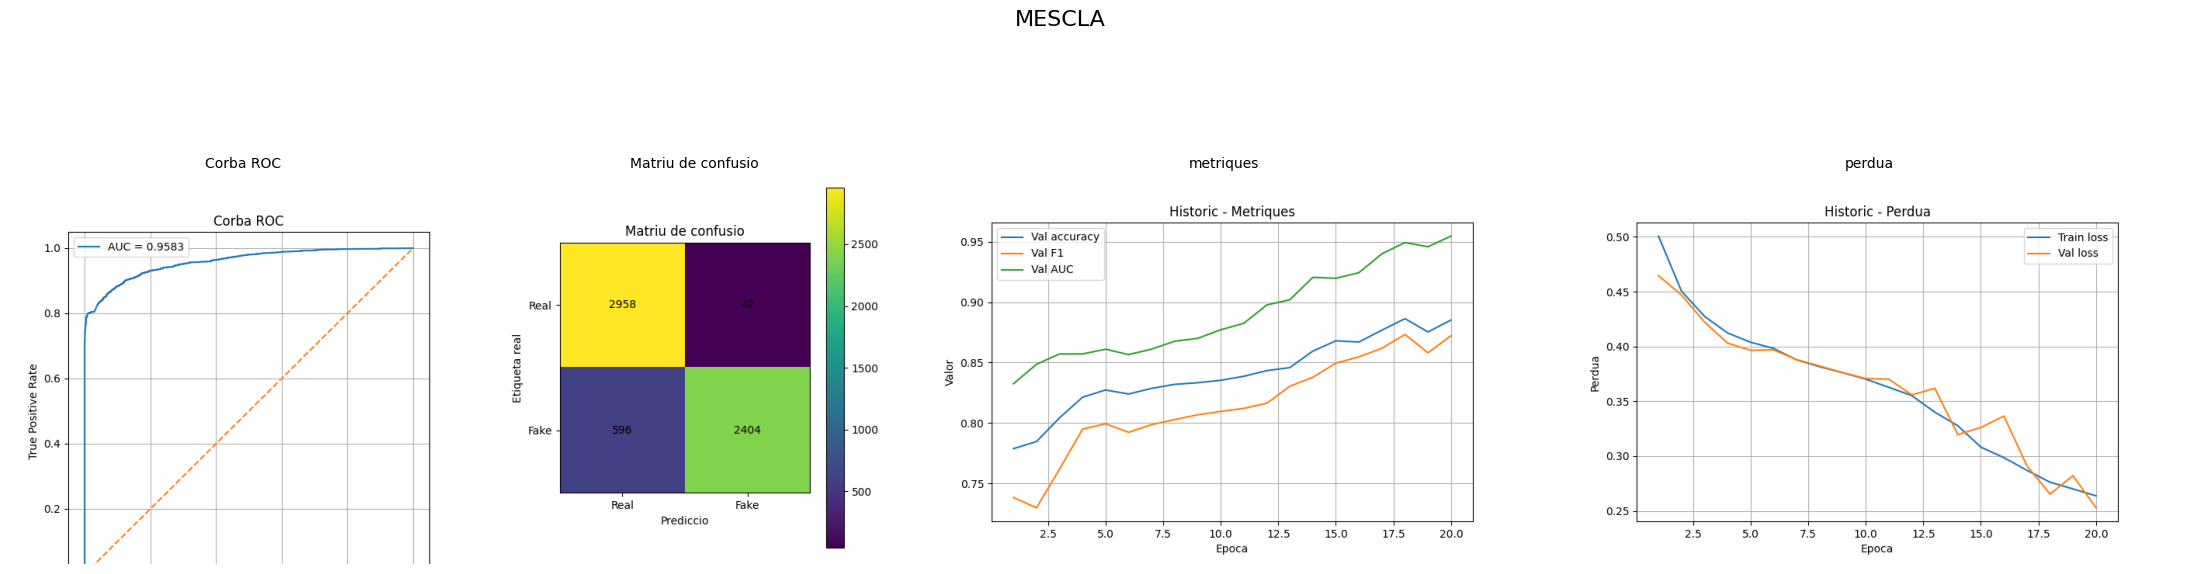

Nom experiment: MESCLA
Metode fake: None
Num epoques: 20
Batch size: 16
Learning rate: 0.001
Test loss: 0.24363902019460995
Accuracy: 0.8936666666666667
Precision: 0.9828291087489779
Recall: 0.8013333333333333
F1: 0.8828497980168931
AUC: 0.9583304444444444


In [7]:
contingut_mescla = carrega_json(RUTA_MESCLA / "metriques.json")

print("\n" + "=" * 60)
print("Experiment MESCLA")
print("=" * 60)

mostra_grafics(RUTA_MESCLA / "grafics", titol="MESCLA")
mostra_resum_metriques(contingut_mescla)

## RESUM GLOBAL

In [8]:
files_resultats = []

for metode in METODES_FAKE:
    contingut = carrega_json(RUTA_1VS1 / metode / "metriques.json")
    metriques = contingut["Metriques"]

    files_resultats.append({
        "experiment": "1VS1",
        "metode": metode,
        "test_loss": contingut["Test loss"],
        "accuracy": metriques["accuracy"],
        "precision": metriques["precision"],
        "recall": metriques["recall"],
        "f1": metriques["f1"],
        "auc": metriques["auc"]
    })

contingut_mescla = carrega_json(RUTA_MESCLA / "metriques.json")
metriques_mescla = contingut_mescla["Metriques"]

files_resultats.append({
    "experiment": "MESCLA",
    "metode": "mescla",
    "test_loss": contingut_mescla["Test loss"],
    "accuracy": metriques_mescla["accuracy"],
    "precision": metriques_mescla["precision"],
    "recall": metriques_mescla["recall"],
    "f1": metriques_mescla["f1"],
    "auc": metriques_mescla["auc"]
})

df_resultats = pd.DataFrame(files_resultats)
df_resultats.sort_values(by="f1", ascending=False).reset_index(drop=True)

,experiment,metode,test_loss,accuracy,precision,recall,f1,auc
0,1VS1,stargan,0.000131,1.000000,1.000000,1.000000,1.000000,1.000000
1,1VS1,pggan_v1,0.004497,0.999164,0.998664,0.999666,0.999165,0.999948
2,1VS1,pggan_v2,0.012203,0.996828,0.996993,0.996660,0.996826,0.999875
3,1VS1,stylegan_celeba,0.020552,0.992167,0.984893,0.999667,0.992225,0.999924
4,MESCLA,mescla,0.243639,0.893667,0.982829,0.801333,0.882850,0.958330
5,1VS1,stylegan_ffhq,0.693164,0.499917,0.499917,1.000000,0.666593,0.500000


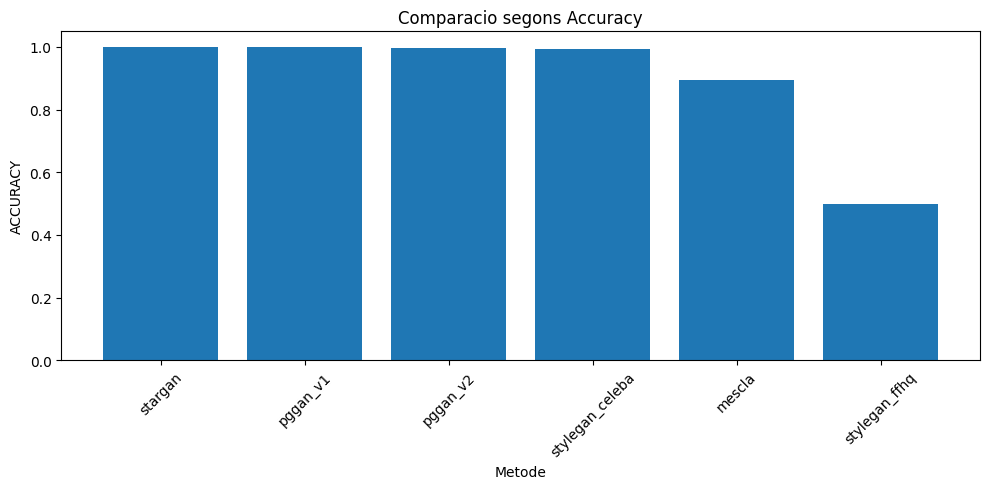

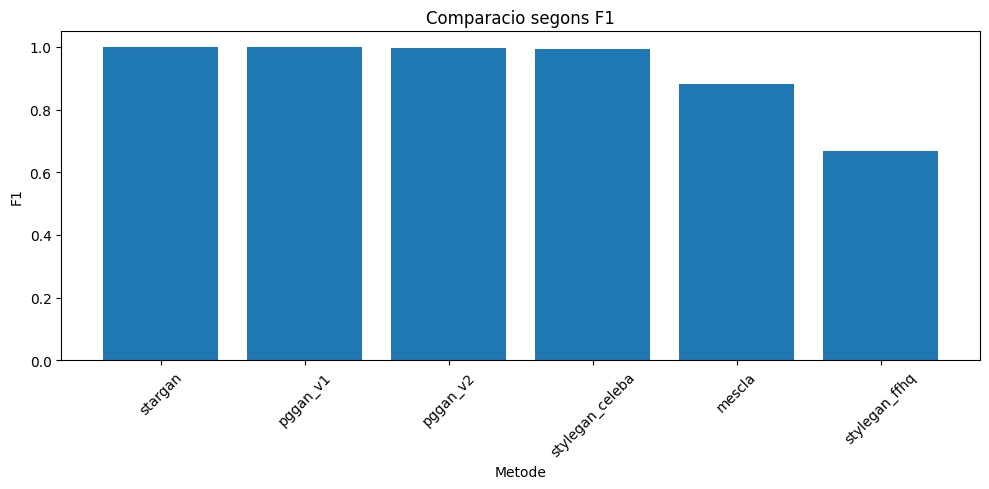

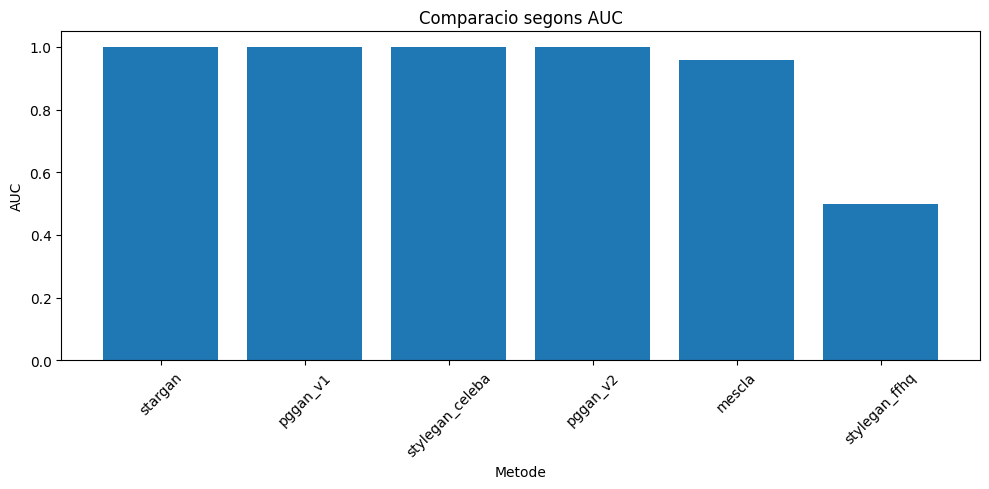

In [9]:
dibuixa_comparacio_metodes(df_resultats, metrica="accuracy", titol="Comparacio segons Accuracy")
dibuixa_comparacio_metodes(df_resultats, metrica="f1", titol="Comparacio segons F1")
dibuixa_comparacio_metodes(df_resultats, metrica="auc", titol="Comparacio segons AUC")